1. Considere os seguintes sistemas de controle em malha aberta:


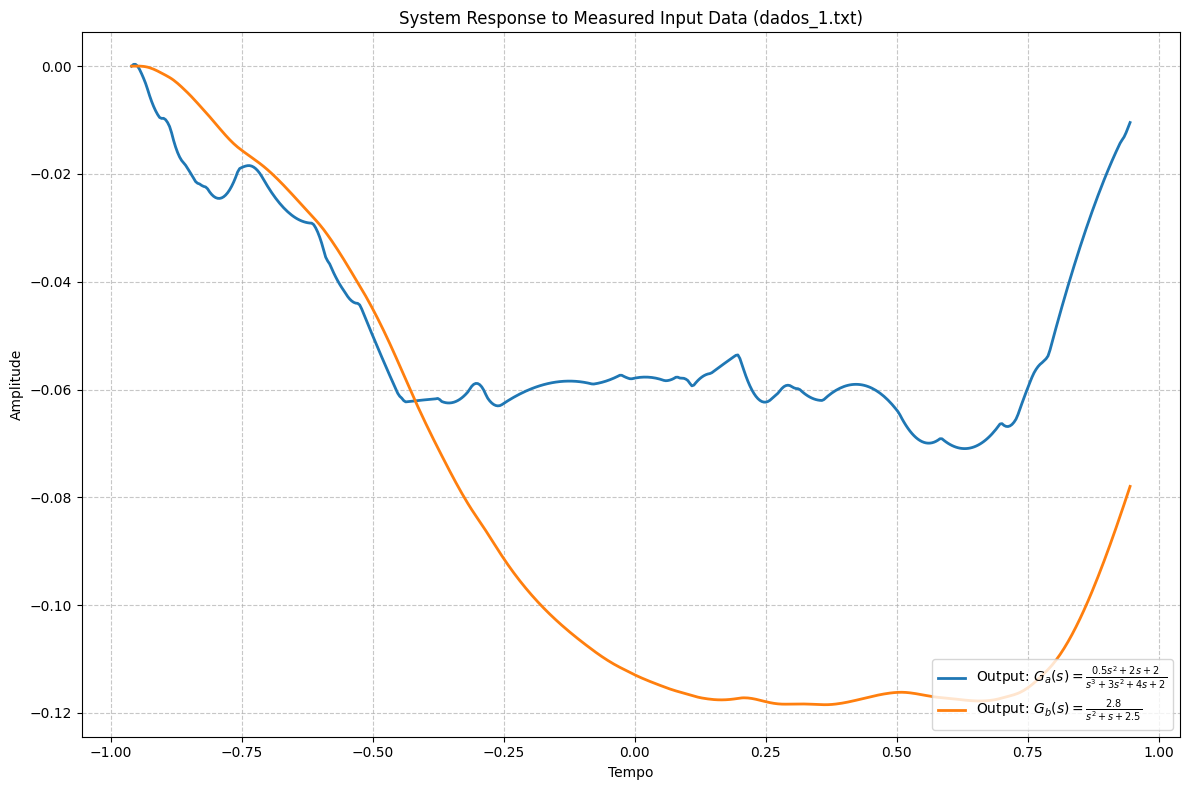

In [ ]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

def load_and_resample_dataset(file_path):
    """
    Carrega e reamostra o dataset de entrada.
    """
    u_data, t_data = np.loadtxt(file_path, delimiter=None, unpack=True)

    sort_idx = np.argsort(t_data)
    t_data: float = t_data[sort_idx]
    u_data: float = u_data[sort_idx]
    t_uniform = np.linspace(t_data[0], t_data[-1], len(t_data))
    u_uniform = np.interp(t_uniform, t_data, u_data)
    
    return t_data, u_data, t_uniform, u_uniform



s = ct.tf('s')

ga = (0.5*s**2 + 2*s + 2) / (s**3 + 3*s**2 + 4*s +2)

gb = 2.8 / (s**2 + s + 2.5)

systems = [ga, gb]

labels = [
    r'$G_a(s) = \frac{0.5s^2 + 2s + 2}{s^3 + 3s^2 + 4s + 2}$',
    r'$G_b(s) = \frac{2.8}{s^2 + s + 2.5}$'
]

t_data, u_data, t_uniform, u_uniform = load_and_resample_dataset('dataset/dados_1.txt')

plt.figure(figsize=(12, 8))
for sys, label in zip(systems, labels):
    time, response = ct.forced_response(sys, T=t_uniform, U=u_uniform)
    plt.plot(time, response, label=f'Output: {label}', linewidth=2)

plt.title(f'System Response to Measured Input Data (dados_1.txt)')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Resposta ao degrau unitário
  G_a: 100 pontos, t ∈ [0, 6.908] s, y_final ≈ 0.998802
  G_b: 100 pontos, t ∈ [0, 13.82] s, y_final ≈ 1.119978


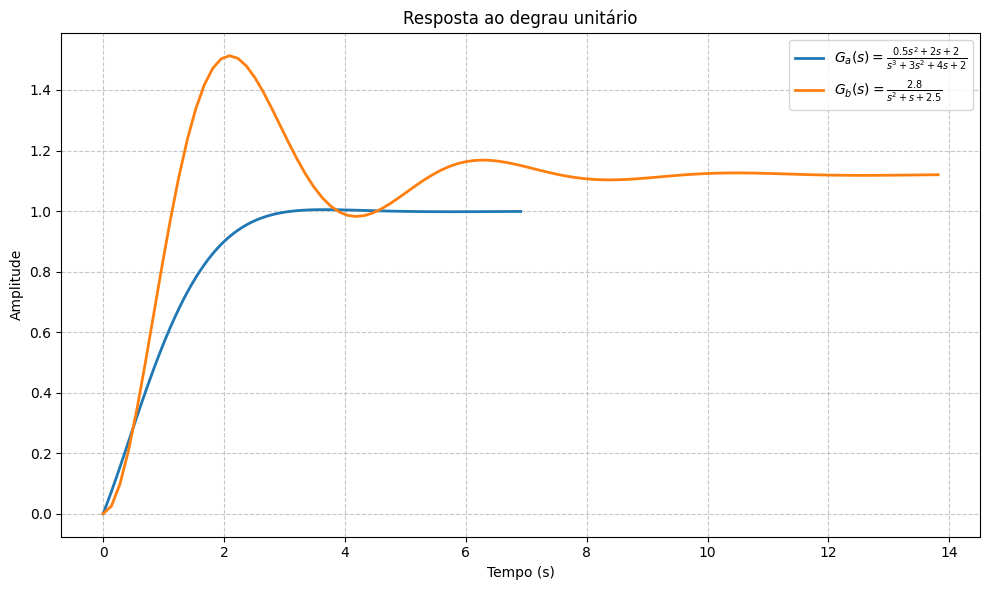

In [ ]:
# Resposta ao degrau unitário
fig_step, ax_step = plt.subplots(figsize=(10, 6))
print('Resposta ao degrau unitário')
for sys, label, name in zip(systems, labels, ['G_a', 'G_b']):
    t_step, y_step = ct.step_response(sys)
    ax_step.plot(t_step, y_step, label=label, linewidth=2)
    print(f'  {name}: {len(t_step)} pontos, t ∈ [{t_step[0]:.4g}, {t_step[-1]:.4g}] s, y_final ≈ {y_step[-1]:.6f}')

ax_step.set_title('Resposta ao degrau unitário')
ax_step.set_xlabel('Tempo (s)')
ax_step.set_ylabel('Amplitude')
ax_step.legend(loc='best')
ax_step.grid(True, linestyle='--', alpha=0.7)
fig_step.tight_layout()
plt.show()


## Análise em função dos polos

**Sistema**
$G_a(s)=\dfrac{0.5s^2+2s+2}{s^3+3s^2+4s+2}$ 

O denominador fatora como \($(s+1)(s^2+2s+2)$\), logo os **polos** são \($s=-1$\) (real) e \($s=-1\pm j$\) (par complexo conjugado). Todos no semiplano esquerdo: o sistema é **BIBO estável**. O numerador é $0.5(s+2)^2$, portanto há **dois zeros em** $s=-2$ (mais à esquerda que os polos). O ganho em regime permanente é $G_a(0)=2/2=1$.

O par $s=-1\pm j$ corresponde a um modo **subamortecido** com frequência natural $\omega_n=\sqrt{2}\,\mathrm{rad/s}$ e amortecimento $\zeta=1/\sqrt{2}\approx 0{,}707$ (resposta oscilatória com amortecimento moderado). O polo real em \(-1\) introduz um modo exponencial com a **mesma parte real** que o par complexo, o que tende a **misturar** exponencial e oscilação sem um “batimento” extremo entre escalas de tempo muito diferentes. Os zeros em \(-2\) puxam a resposta no sentido de **reduzir sobressinal** e acelerar o alinhamento ao valor final em relação a um sistema só com o par complexo, porque estão relativamente próximos do eixo imaginário e à esquerda dos polos dominantes.

**Sistema** $G_b(s)=\dfrac{2.8}{s^2+s+2.5}$  
É de **2ª ordem** com polos $s=-0{,}5\pm j1{,}5$. Da forma $s^2+2\zeta\omega_n s+\omega_n^2$ obtém-se $\omega_n=\sqrt{2{,}5}\,\mathrm{rad/s}$ e $\zeta=\dfrac{1}{2\sqrt{2{,}5}}\approx 0{,}316$. Não há zeros finitos: dinâmica puramente do par de polos. O ganho DC é $G_b(0)=2{,}8/2{,}5=1{,}12$.

Com $\zeta<0{,}5$, o sistema é **mais subamortecido** que o modo oscilatório de $G_a$: espera-se **maior sobressinal** e oscilações mais acentuadas antes do estabelecimento. A parte real dos polos é $-0{,}5$, **menos negativa** que a de $(G_a) ((-1))$, logo os modos de $(G_b)$ decaem em geral **mais devagar** que os de \(G_a\) (resposta mais “lenta” em termos de envoltória).

**Comparando os dois**  
Ambos são estáveis e exibem oscilação devido aos polos complexos, mas **$(G_b)$** tem **menor amortecimento relativo** ($(\zeta) menor$) e **polos mais próximos do eixo imaginário**, o que explica maior oscilação e estabelecimento mais lento; **$(G_a)$** combina três polos (um real + um par complexo) com **dois zeros** que moldam a forma da resposta e ganho DC unitário, enquanto **$(G_b)$** tende a um valor final **ligeiramente acima de 1** por causa do ganho estático.


In [ ]:
import numpy as np

# Discretização ZOH (equivalência ao retentor de ordem zero)
Ts = 0.1  # s
ga_d = ct.c2d(ga, Ts, method='zoh')
gb_d = ct.c2d(gb, Ts, method='zoh')

print(f'Funções de transferência discretas (ZOH), Ts = {Ts} s\n')
print('G_a(z) =')
print(ga_d)
print()
print('G_b(z) =')
print(gb_d)


def _poly_z_str(coeffs):
    """Coeficientes em potências decrescentes de z: c0*z^n + c1*z^(n-1) + ..."""
    c = np.asarray(coeffs, dtype=float)
    deg = len(c) - 1
    s = ''
    first = True
    for i, ak in enumerate(c):
        if abs(ak) < 1e-12:
            continue
        p = deg - i
        if p == 0:
            t = f'{abs(ak):.6g}'
        elif p == 1:
            t = f'{abs(ak):.6g} z'
        else:
            t = f'{abs(ak):.6g} z^{p}'
        if first:
            s += ('-' if ak < 0 else '') + t
            first = False
        else:
            s += (' + ' if ak >= 0 else ' - ') + t
    return s if s else '0'


def explicit_Gz_and_diffeq(label, sys_d):
    """G(z)=N/D e sum_i den[i] y[k-i] = sum_j num[j] u[k-1-j] (causal)."""
    num = np.array(sys_d.num[0][0], dtype=float)
    den = np.array(sys_d.den[0][0], dtype=float)
    print(f'\n--- {label} ---')
    print('Forma racional explícita (potências decrescentes de z):')
    print(f'  {label}(z) = ({_poly_z_str(num)}) / ({_poly_z_str(den)})')

    lhs = f'{den[0]:.6g} y[k]'
    for i in range(1, len(den)):
        a = den[i]
        lhs += f' {"+" if a >= 0 else "-"} {abs(a):.6g} y[k-{i}]'

    rhs = f'{num[0]:.6g} u[k-1]'
    for j in range(1, len(num)):
        a = num[j]
        rhs += f' {"+" if a >= 0 else "-"} {abs(a):.6g} u[k-{j+1}]'

    print('Equação às diferenças (relação causal padrão Y(z)D(z) = U(z)N(z)):')
    print(f'  {lhs} = {rhs}')


explicit_Gz_and_diffeq('G_a', ga_d)
explicit_Gz_and_diffeq('G_b', gb_d)


Funções de transferência discretas (ZOH), Ts = 0.1 s

G_a(z) =
<TransferFunction>: sys[25]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

   0.05226 z^2 - 0.08553 z + 0.035
  ----------------------------------
  z^3 - 2.705 z^2 + 2.448 z - 0.7408

G_b(z) =
<TransferFunction>: sys[33]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

   0.01352 z + 0.01307
  ----------------------
  z^2 - 1.881 z + 0.9048

--- G_a ---
Forma racional explícita (potências decrescentes de z):
  G_a(z) = (0.0522563 z^2 - 0.0855332 z + 0.0349991) / (1 z^3 - 2.70547 z^2 + 2.44801 z - 0.740818)
Equação às diferenças (relação causal padrão Y(z)D(z) = U(z)N(z)):
  1 y[k] - 2.70547 y[k-1] + 2.44801 y[k-2] - 0.740818 y[k-3] = 0.0522563 u[k-1] - 0.0855332 u[k-2] + 0.0349991 u[k-3]

--- G_b ---
Forma racional explícita (potências decrescentes de z):
  G_b(z) = (0.0135168 z + 0.0130733) / (1 z^2 - 1.8811 z + 0.904837)
Equação às diferenças (relação causal padrão Y(z)D(z) = U(z)N(z)):
  1 y[k]

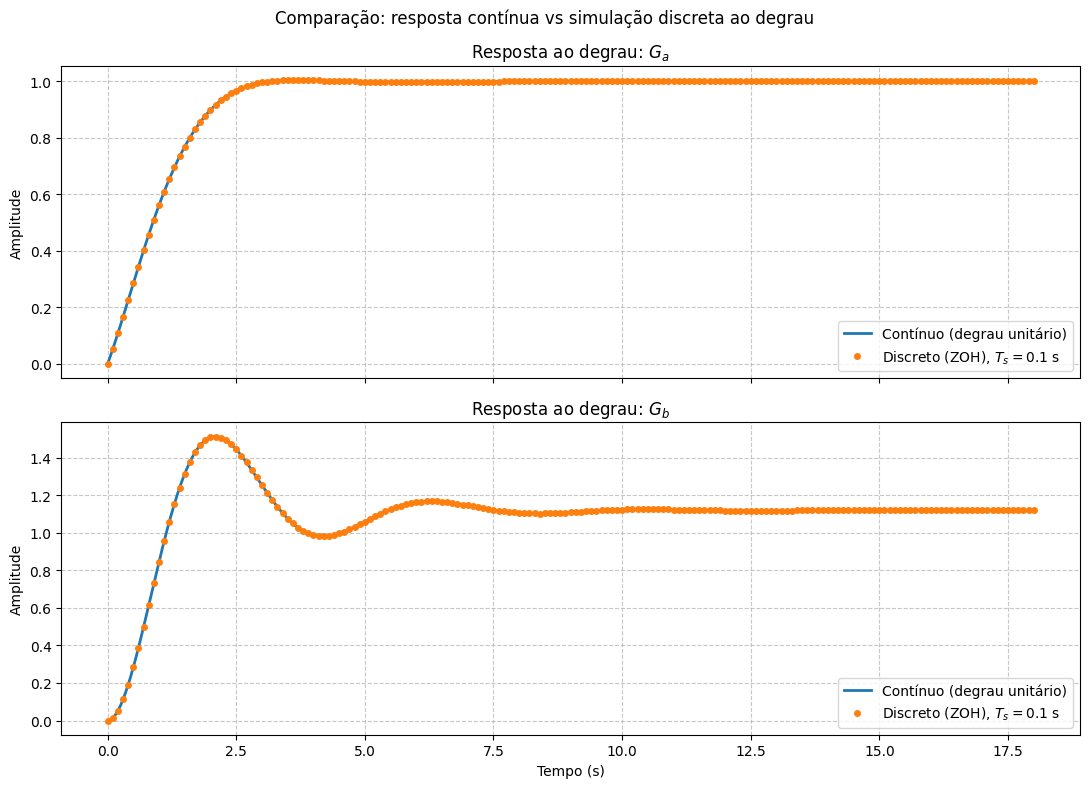

In [ ]:
# Mesmo horizonte para ambos; contínuo denso, discreto nos instantes k*Ts
t_end = 18.0
t_cont = np.linspace(0.0, t_end, 2000)
t_disc = np.arange(0.0, t_end + Ts / 2, Ts)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
pairs = [(ga, ga_d, r'$G_a$'), (gb, gb_d, r'$G_b$')]

for ax, (sys_c, sys_d, name) in zip(axes, pairs):
    tc, yc = ct.step_response(sys_c, T=t_cont)
    td, yd = ct.step_response(sys_d, T=t_disc)
    ax.plot(tc, yc, '-', color='C0', linewidth=2, label='Contínuo (degrau unitário)')
    ax.plot(td, yd, 'o', color='C1', markersize=4, label=f'Discreto (ZOH), $T_s={Ts}$ s')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Resposta ao degrau: {name}')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='lower right')

axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('Comparação: resposta contínua vs simulação discreta ao degrau')
plt.tight_layout()
plt.show()
